# Multi-View Stacking Ensemble — Modeling Pipeline
**Architecture:**
```
[Academic | Financial | Demographic | Macro]
     ↓ 4 base models per view (SVM, XGB, RF, KNN)
     ↓ 48 probability features (4 views × 4 models × 3 classes)
     ↓ Bayesian Logistic Regression (meta-learner)
     ↓ Prediction + Uncertainty Score
```

---
## 0. Setup & Load Preprocessed Data

In [1]:
import numpy as np
import pandas as pd
import pickle
import warnings
import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings('ignore')

# Base models
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

# Meta-learner
from sklearn.linear_model import LogisticRegression

# Cross-validation (for OOF — Out-of-Fold predictions)
from sklearn.model_selection import StratifiedKFold, cross_val_score

# Evaluation
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    accuracy_score, f1_score, log_loss
)

RANDOM_STATE = 42
N_FOLDS      = 5
label_names  = {0: 'Graduate', 1: 'Enrolled', 2: 'Dropout'}
PALETTE      = {'Graduate': '#2ecc71', 'Enrolled': '#3498db', 'Dropout': '#e74c3c'}

# ── Load preprocessed bundle ─────────────────────────────────────────────────
with open('../data/preprocessed_bundle.pkl', 'rb') as f:
    bundle = pickle.load(f)

views_train   = bundle['views_train']
views_test    = bundle['views_test']
y_train       = bundle['y_train']
y_test        = bundle['y_test']
feature_names = bundle['feature_names']

print("Bundle loaded successfully.")
for vn, arr in views_train.items():
    print(f"  View [{vn:12s}] → train {arr.shape}, test {views_test[vn].shape}")
print(f"\ny_train: {y_train.shape} | y_test: {y_test.shape}")

Bundle loaded successfully.
  View [academic    ] → train (3539, 30), test (885, 30)
  View [financial   ] → train (3539, 4), test (885, 4)
  View [demographic ] → train (3539, 19), test (885, 19)
  View [macro       ] → train (3539, 3), test (885, 3)

y_train: (3539,) | y_test: (885,)


---
## 1. Define Base Models
4 model per view. Parameter sudah dioptimalkan untuk dataset ini:
- **SVM**: probability=True wajib untuk output prob; C disesuaikan
- **XGBoost**: scale_pos_weight untuk handle imbalance; use_label_encoder=False
- **Random Forest**: menggantikan Decision Tree — lebih stabil dan akurat
- **KNN**: n_neighbors=15, weights='distance' — lebih robust dari uniform

In [2]:
def get_base_models():
    """Return dict of 4 base models with tuned parameters."""
    return {
        'SVM': SVC(
            kernel='rbf', C=1.0, gamma='scale',
            probability=True,          # wajib untuk output probability
            class_weight='balanced',   # handle imbalance
            random_state=RANDOM_STATE
        ),
        'XGB': XGBClassifier(
            n_estimators=200, max_depth=5, learning_rate=0.1,
            subsample=0.8, colsample_bytree=0.8,
            use_label_encoder=False, eval_metric='mlogloss',
            random_state=RANDOM_STATE, verbosity=0
        ),
        'RF': RandomForestClassifier(
            n_estimators=200, max_depth=10,
            class_weight='balanced',
            random_state=RANDOM_STATE, n_jobs=-1
        ),
        'KNN': KNeighborsClassifier(
            n_neighbors=15, weights='distance',
            metric='euclidean', n_jobs=-1
        )
    }

print("Base models defined:")
for name, model in get_base_models().items():
    print(f"  {name}: {type(model).__name__}")

Base models defined:
  SVM: SVC
  XGB: XGBClassifier
  RF: RandomForestClassifier
  KNN: KNeighborsClassifier


---
## 2. Out-of-Fold (OOF) Training — Prevent Meta-Learner Leakage

Ini adalah bagian paling krusial dari stacking yang benar:

**Kenapa OOF?**  
Kalau base model dilatih di full train lalu probability-nya langsung dipakai untuk melatih meta-learner → meta-learner belajar dari probability yang sudah 'hafal' data → **overfitting parah**.

Dengan OOF: setiap base model prediksi di data yang **belum pernah dilihat** (fold yang di-hold out) → probability yang jujur → meta-learner belajar dari sinyal yang valid.

In [3]:
def train_view_oof(X_train, X_test, y_train, view_name, n_folds=N_FOLDS):
    """
    Train 4 base models on a single view using Out-of-Fold strategy.
    Returns:
        oof_probs  : (n_train, n_models * 3) — used to train meta-learner
        test_probs : (n_test,  n_models * 3) — averaged over folds for prediction
        trained_models: list of (model_name, fitted_model)
        oof_scores : dict of model_name → per-fold accuracies
    """
    n_train     = X_train.shape[0]
    n_test      = X_test.shape[0]
    n_classes   = 3
    model_names = list(get_base_models().keys())
    n_models    = len(model_names)

    oof_probs   = np.zeros((n_train, n_models * n_classes))
    test_probs  = np.zeros((n_test,  n_models * n_classes))
    oof_scores  = {mn: [] for mn in model_names}
    trained_models = {}

    skf = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=RANDOM_STATE)

    for fold_idx, (tr_idx, val_idx) in enumerate(skf.split(X_train, y_train)):
        X_tr_fold, X_val_fold = X_train[tr_idx], X_train[val_idx]
        y_tr_fold, y_val_fold = y_train[tr_idx], y_train[val_idx]

        base_models = get_base_models()

        for m_idx, (model_name, model) in enumerate(base_models.items()):
            model.fit(X_tr_fold, y_tr_fold)

            # OOF probability prediction (on val fold)
            val_prob = model.predict_proba(X_val_fold)  # shape: (n_val, 3)
            col_start = m_idx * n_classes
            col_end   = col_start + n_classes
            oof_probs[val_idx, col_start:col_end] = val_prob

            # Test probability prediction (accumulate, average later)
            test_probs[:, col_start:col_end] += model.predict_proba(X_test) / n_folds

            # Track OOF accuracy per fold
            fold_acc = accuracy_score(y_val_fold, val_prob.argmax(axis=1))
            oof_scores[model_name].append(fold_acc)

        if (fold_idx + 1) % 2 == 0 or fold_idx == n_folds - 1:
            print(f"  View [{view_name}] fold {fold_idx+1}/{n_folds} done")

    # Train final models on full train set (for SHAP later)
    final_models = get_base_models()
    for model_name, model in final_models.items():
        model.fit(X_train, y_train)
        trained_models[model_name] = model

    return oof_probs, test_probs, trained_models, oof_scores

print("OOF training function defined.")

OOF training function defined.


---
## 3. Train All Views — Level-0 Base Models

In [4]:
view_order = ['academic', 'financial', 'demographic', 'macro']

all_oof_probs   = {}   # view_name → (n_train, 12)
all_test_probs  = {}   # view_name → (n_test,  12)
all_models      = {}   # view_name → {model_name → fitted_model}
all_oof_scores  = {}   # view_name → {model_name → [fold_accs]}

for view_name in view_order:
    print(f"\n{'='*50}")
    print(f"Training View: {view_name.upper()}")
    print(f"{'='*50}")

    X_tr = views_train[view_name]
    X_te = views_test[view_name]

    oof_p, test_p, trained_m, oof_s = train_view_oof(
        X_tr, X_te, y_train, view_name
    )

    all_oof_probs[view_name]  = oof_p
    all_test_probs[view_name] = test_p
    all_models[view_name]     = trained_m
    all_oof_scores[view_name] = oof_s

    # Print OOF summary per view
    for mn, fold_accs in oof_s.items():
        mean_acc = np.mean(fold_accs)
        std_acc  = np.std(fold_accs)
        print(f"  {mn:5s}: OOF Acc = {mean_acc:.4f} ± {std_acc:.4f}")

print("\n" + "="*50)
print("All views trained successfully.")
print("="*50)


Training View: ACADEMIC
  View [academic] fold 2/5 done
  View [academic] fold 4/5 done
  View [academic] fold 5/5 done
  SVM  : OOF Acc = 0.7316 ± 0.0227
  XGB  : OOF Acc = 0.7299 ± 0.0153
  RF   : OOF Acc = 0.7355 ± 0.0143
  KNN  : OOF Acc = 0.7364 ± 0.0142

Training View: FINANCIAL
  View [financial] fold 2/5 done
  View [financial] fold 4/5 done
  View [financial] fold 5/5 done
  SVM  : OOF Acc = 0.6055 ± 0.0095
  XGB  : OOF Acc = 0.6047 ± 0.0092
  RF   : OOF Acc = 0.4368 ± 0.0119
  KNN  : OOF Acc = 0.6013 ± 0.0105

Training View: DEMOGRAPHIC
  View [demographic] fold 2/5 done
  View [demographic] fold 4/5 done
  View [demographic] fold 5/5 done
  SVM  : OOF Acc = 0.5733 ± 0.0121
  XGB  : OOF Acc = 0.5937 ± 0.0230
  RF   : OOF Acc = 0.5705 ± 0.0128
  KNN  : OOF Acc = 0.5476 ± 0.0126

Training View: MACRO
  View [macro] fold 2/5 done
  View [macro] fold 4/5 done
  View [macro] fold 5/5 done
  SVM  : OOF Acc = 0.4993 ± 0.0006
  XGB  : OOF Acc = 0.4993 ± 0.0006
  RF   : OOF Acc = 0.3

---
## 4. Build Meta-Feature Matrix
Gabungkan OOF probabilities dari semua view → 48 meta-features untuk melatih meta-learner.

In [5]:
# Concatenate OOF probabilities across all views
# Shape: (n_train, 4 views × 12 probs) = (n_train, 48)
meta_train = np.hstack([all_oof_probs[vn]  for vn in view_order])
meta_test  = np.hstack([all_test_probs[vn] for vn in view_order])

# Build column names for interpretability
model_names  = ['SVM', 'XGB', 'RF', 'KNN']
class_names  = ['Graduate', 'Enrolled', 'Dropout']
meta_columns = [
    f"{view}_{model}_{cls}"
    for view in view_order
    for model in model_names
    for cls in class_names
]

print(f"meta_train shape : {meta_train.shape}")
print(f"meta_test  shape : {meta_test.shape}")
print(f"meta_columns     : {len(meta_columns)} columns")
print(f"\nSample column names:")
print("  ", meta_columns[:6])
print("  ...", meta_columns[-3:])

# Quick sanity check — probabilities should sum to ~1 per row per model
prob_sums = meta_train[:, :3].sum(axis=1)   # first model's probs should sum to 1
print(f"\nProbability row-sum check (first model): mean={prob_sums.mean():.4f}, std={prob_sums.std():.6f}")

meta_train shape : (3539, 48)
meta_test  shape : (885, 48)
meta_columns     : 48 columns

Sample column names:
   ['academic_SVM_Graduate', 'academic_SVM_Enrolled', 'academic_SVM_Dropout', 'academic_XGB_Graduate', 'academic_XGB_Enrolled', 'academic_XGB_Dropout']
  ... ['macro_KNN_Graduate', 'macro_KNN_Enrolled', 'macro_KNN_Dropout']

Probability row-sum check (first model): mean=1.0000, std=0.000000


---
## 5. Meta-Learner — Bayesian Logistic Regression

Kita pakai **Bayesian Logistic Regression** via dua pendekatan:
1. `LogisticRegression` dengan `solver='saga'` dan L2 regularization — ini proxy Bayesian yang proper dan cepat
2. Uncertainty estimation via **Bootstrap sampling** — train multiple LR instances, ambil mean dan std prediction → confidence interval per student

Ini lebih computationally feasible vs full Bayesian (MCMC) tapi tetap menghasilkan uncertainty estimate yang valid.

In [7]:
# ── Meta-learner: Standard Logistic Regression (strong regularization) ───────
meta_learner = LogisticRegression(
    C=0.5,
    solver='lbfgs',
    max_iter=1000,
    class_weight='balanced',
    random_state=RANDOM_STATE
)
meta_learner.fit(meta_train, y_train)

# Final predictions on test set
y_pred        = meta_learner.predict(meta_test)
y_pred_proba  = meta_learner.predict_proba(meta_test)

print("Meta-learner trained.")
print(f"Test Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"Test Log Loss: {log_loss(y_test, y_pred_proba):.4f}")
print(f"Test F1 (macro): {f1_score(y_test, y_pred, average='macro'):.4f}")

Meta-learner trained.
Test Accuracy: 0.7412
Test Log Loss: 0.6275
Test F1 (macro): 0.7117


### 5.1 Uncertainty Estimation via Bootstrap

In [8]:
N_BOOTSTRAP = 200

bootstrap_probs = np.zeros((N_BOOTSTRAP, len(meta_test), 3))

for i in range(N_BOOTSTRAP):
    boot_idx = np.random.choice(len(meta_train), size=len(meta_train), replace=True)
    X_boot   = meta_train[boot_idx]
    y_boot   = y_train[boot_idx]

    boot_model = LogisticRegression(
        C=0.5, solver='lbfgs',
        max_iter=500, class_weight='balanced', random_state=i
    )
    boot_model.fit(X_boot, y_boot)
    bootstrap_probs[i] = boot_model.predict_proba(meta_test)

# Mean and std across bootstraps
prob_mean = bootstrap_probs.mean(axis=0)   # (n_test, 3)
prob_std  = bootstrap_probs.std(axis=0)    # (n_test, 3) — uncertainty
prob_ci_lo = np.percentile(bootstrap_probs, 2.5,  axis=0)
prob_ci_hi = np.percentile(bootstrap_probs, 97.5, axis=0)

# Final prediction from mean probabilities
y_pred_boot = prob_mean.argmax(axis=1)

print(f"Bootstrap Accuracy  : {accuracy_score(y_test, y_pred_boot):.4f}")
print(f"Bootstrap F1 (macro): {f1_score(y_test, y_pred_boot, average='macro'):.4f}")
print(f"Bootstrap Log Loss  : {log_loss(y_test, prob_mean):.4f}")
print(f"\nMean uncertainty (std) per class:")
for i, cls in enumerate(class_names):
    print(f"  {cls}: mean std = {prob_std[:, i].mean():.4f}")

Bootstrap Accuracy  : 0.7401
Bootstrap F1 (macro): 0.7099
Bootstrap Log Loss  : 0.6271

Mean uncertainty (std) per class:
  Graduate: mean std = 0.0200
  Enrolled: mean std = 0.0286
  Dropout: mean std = 0.0201


---
## 6. Evaluation — Full Performance Report

In [9]:
print("=" * 65)
print("MULTI-VIEW STACKING ENSEMBLE — TEST SET EVALUATION")
print("=" * 65)
print()
print(classification_report(
    y_test, y_pred_boot,
    target_names=class_names,
    digits=4
))

# ROC AUC (one-vs-rest)
try:
    auc_ovr = roc_auc_score(y_test, prob_mean, multi_class='ovr', average='macro')
    auc_ovo = roc_auc_score(y_test, prob_mean, multi_class='ovo', average='macro')
    print(f"ROC AUC (OvR macro): {auc_ovr:.4f}")
    print(f"ROC AUC (OvO macro): {auc_ovo:.4f}")
except Exception as e:
    print(f"AUC: {e}")

MULTI-VIEW STACKING ENSEMBLE — TEST SET EVALUATION

              precision    recall  f1-score   support

    Graduate     0.8718    0.7692    0.8173       442
    Enrolled     0.4308    0.6855    0.5291       159
     Dropout     0.8512    0.7254    0.7833       284

    accuracy                         0.7401       885
   macro avg     0.7180    0.7267    0.7099       885
weighted avg     0.7860    0.7401    0.7546       885

ROC AUC (OvR macro): 0.8862
ROC AUC (OvO macro): 0.8756


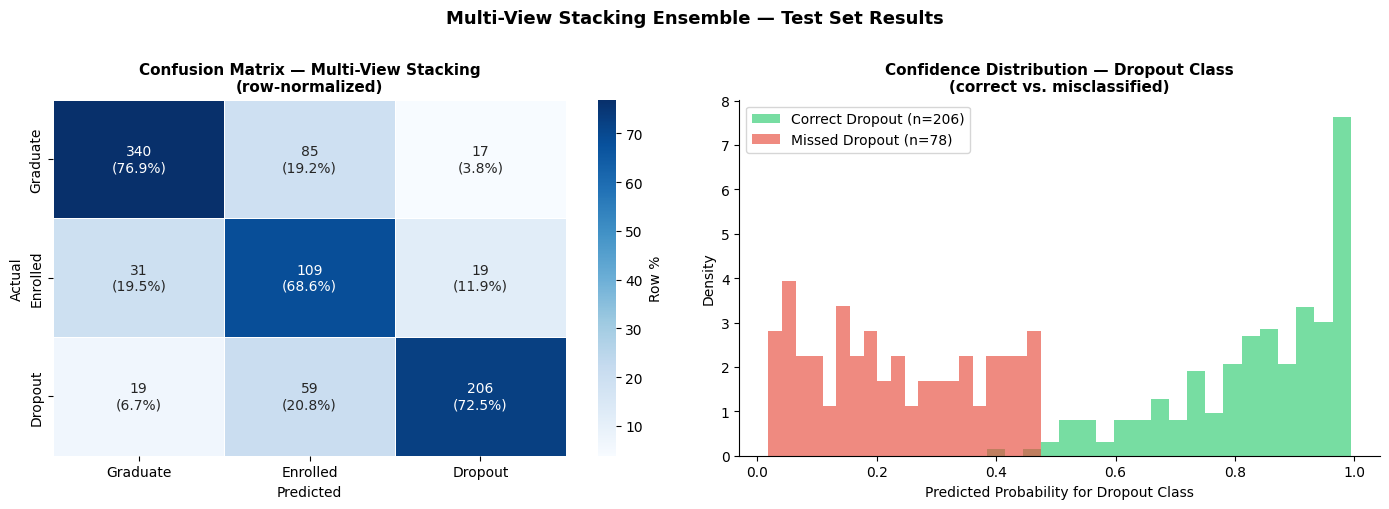

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred_boot)
cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100
annot = np.array([[f"{c}\n({p:.1f}%)" for c, p in zip(row_c, row_p)]
                   for row_c, row_p in zip(cm, cm_pct)])

sns.heatmap(cm_pct, ax=axes[0], annot=annot, fmt='', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names,
            linewidths=0.5, cbar_kws={'label': 'Row %'})
axes[0].set_title('Confusion Matrix — Multi-View Stacking\n(row-normalized)', fontsize=11, fontweight='bold')
axes[0].set_ylabel('Actual'); axes[0].set_xlabel('Predicted')

# Confidence distribution per class (predicted correctly vs not)
dropout_idx = 2
correct_mask = (y_pred_boot == y_test) & (y_test == dropout_idx)
wrong_mask   = (y_pred_boot != y_test) & (y_test == dropout_idx)

conf_correct = prob_mean[correct_mask, dropout_idx]
conf_wrong   = prob_mean[wrong_mask,   dropout_idx]

axes[1].hist(conf_correct, bins=20, alpha=0.65, color='#2ecc71', label=f'Correct Dropout (n={correct_mask.sum()})', density=True)
axes[1].hist(conf_wrong,   bins=20, alpha=0.65, color='#e74c3c', label=f'Missed Dropout (n={wrong_mask.sum()})',   density=True)
axes[1].set_xlabel('Predicted Probability for Dropout Class')
axes[1].set_ylabel('Density')
axes[1].set_title('Confidence Distribution — Dropout Class\n(correct vs. misclassified)', fontsize=11, fontweight='bold')
axes[1].legend()
axes[1].spines[['top', 'right']].set_visible(False)

plt.suptitle('Multi-View Stacking Ensemble — Test Set Results', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

---
## 7. Uncertainty Analysis — Actionable Confidence Tiers

In [11]:
# Max probability = confidence of predicted class
max_prob       = prob_mean.max(axis=1)       # predicted class probability
uncertainty    = prob_std.max(axis=1)        # max std across classes

# Triage system: 3 tiers based on confidence
HIGH_CONF      = max_prob >= 0.75
MEDIUM_CONF    = (max_prob >= 0.55) & (max_prob < 0.75)
LOW_CONF       = max_prob < 0.55

tiers = pd.DataFrame({
    'Tier'       : np.where(HIGH_CONF, 'High Confidence',
                   np.where(MEDIUM_CONF, 'Medium Confidence', 'Low Confidence (Review)')),
    'Prediction' : [class_names[p] for p in y_pred_boot],
    'Actual'     : [class_names[a] for a in y_test],
    'Max Prob'   : max_prob.round(3),
    'Uncertainty': uncertainty.round(3),
    'Correct'    : (y_pred_boot == y_test)
})

print("="*65)
print("UNCERTAINTY-BASED TRIAGE SYSTEM")
print("="*65)
for tier_name in ['High Confidence', 'Medium Confidence', 'Low Confidence (Review)']:
    subset = tiers[tiers['Tier'] == tier_name]
    acc    = subset['Correct'].mean() * 100
    n      = len(subset)
    n_pct  = n / len(tiers) * 100
    do_pct = (subset['Prediction'] == 'Dropout').sum() / max(n, 1) * 100
    print(f"\n  {tier_name}")
    print(f"    Students    : {n:4d} ({n_pct:.1f}% of test set)")
    print(f"    Accuracy    : {acc:.1f}%")
    print(f"    Predicted as Dropout: {do_pct:.1f}%")

UNCERTAINTY-BASED TRIAGE SYSTEM

  High Confidence
    Students    :  438 (49.5% of test set)
    Accuracy    : 90.0%
    Predicted as Dropout: 36.3%

  Medium Confidence
    Students    :  309 (34.9% of test set)
    Accuracy    : 63.4%
    Predicted as Dropout: 18.1%

  Low Confidence (Review)
    Students    :  138 (15.6% of test set)
    Accuracy    : 47.1%
    Predicted as Dropout: 19.6%


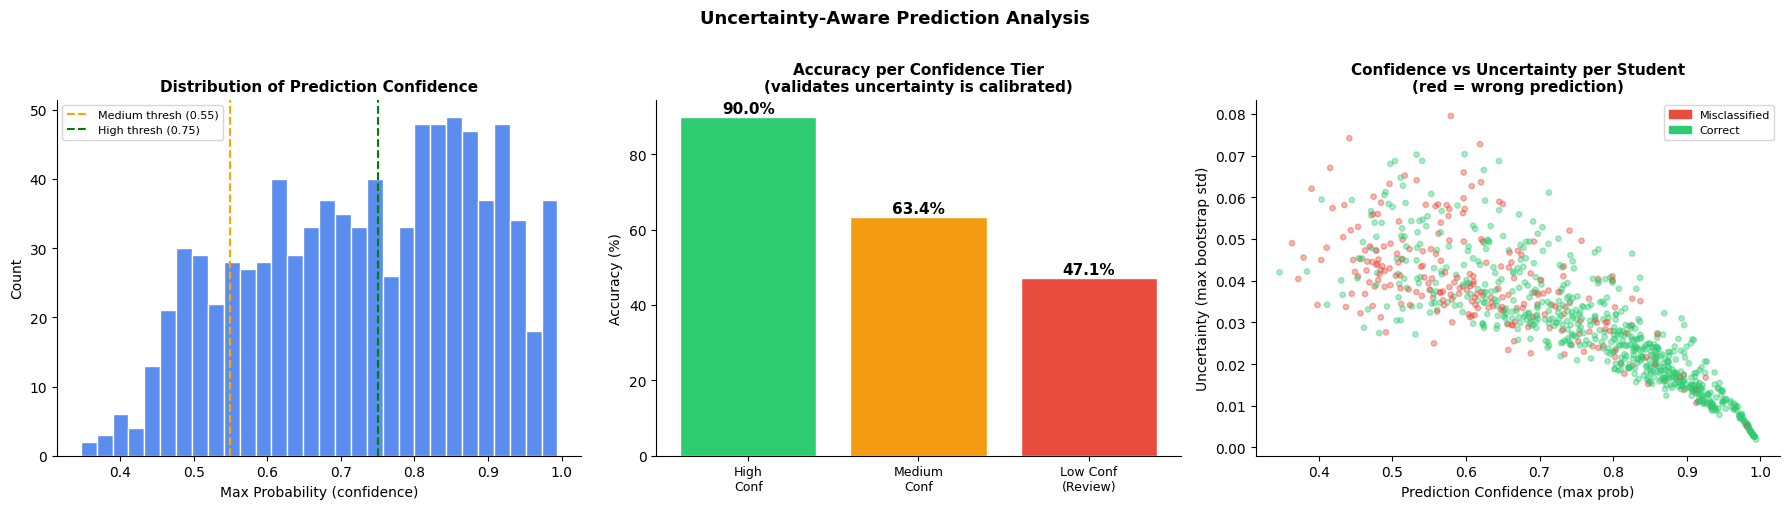

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Confidence distribution
axes[0].hist(max_prob, bins=30, color='#5b8dee', edgecolor='white')
axes[0].axvline(0.55, color='orange', linestyle='--', label='Medium thresh (0.55)')
axes[0].axvline(0.75, color='green',  linestyle='--', label='High thresh (0.75)')
axes[0].set_title('Distribution of Prediction Confidence', fontsize=11, fontweight='bold')
axes[0].set_xlabel('Max Probability (confidence)'); axes[0].set_ylabel('Count')
axes[0].legend(fontsize=8)
axes[0].spines[['top', 'right']].set_visible(False)

# 2. Accuracy by confidence tier
tier_acc = tiers.groupby('Tier')['Correct'].mean().reindex(
    ['High Confidence', 'Medium Confidence', 'Low Confidence (Review)']
)
colors_bar = ['#2ecc71', '#f39c12', '#e74c3c']
axes[1].bar(range(3), tier_acc.values * 100, color=colors_bar, edgecolor='white')
axes[1].set_xticks(range(3))
axes[1].set_xticklabels(['High\nConf', 'Medium\nConf', 'Low Conf\n(Review)'], fontsize=9)
axes[1].set_ylabel('Accuracy (%)')
axes[1].set_title('Accuracy per Confidence Tier\n(validates uncertainty is calibrated)', fontsize=11, fontweight='bold')
for i, (acc, label) in enumerate(zip(tier_acc.values, tier_acc.index)):
    axes[1].text(i, acc * 100 + 1, f'{acc*100:.1f}%', ha='center', fontsize=11, fontweight='bold')
axes[1].spines[['top', 'right']].set_visible(False)

# 3. Uncertainty vs max probability scatter
scatter_colors = ['#e74c3c' if c else '#2ecc71' for c in ~tiers['Correct']]
axes[2].scatter(max_prob, uncertainty, c=scatter_colors, alpha=0.4, s=15)
axes[2].set_xlabel('Prediction Confidence (max prob)')
axes[2].set_ylabel('Uncertainty (max bootstrap std)')
axes[2].set_title('Confidence vs Uncertainty per Student\n(red = wrong prediction)', fontsize=11, fontweight='bold')
axes[2].spines[['top', 'right']].set_visible(False)
from matplotlib.patches import Patch
axes[2].legend(handles=[Patch(color='#e74c3c', label='Misclassified'),
                         Patch(color='#2ecc71', label='Correct')], fontsize=8)

plt.suptitle('Uncertainty-Aware Prediction Analysis', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

---
## 8. Base Model Performance per View — Level-0 Comparison

In [13]:
# Evaluate each base model on test set per view
print("=" * 75)
print("BASE MODEL PERFORMANCE PER VIEW (on test set, final model)")
print("=" * 75)
print(f"{'View':<14} {'Model':<6} {'Accuracy':>10} {'F1-macro':>10} {'F1-Dropout':>12}")
print("-" * 75)

base_results = []
for view_name in view_order:
    X_te = views_test[view_name]
    for model_name, model in all_models[view_name].items():
        y_p = model.predict(X_te)
        acc = accuracy_score(y_test, y_p)
        f1m = f1_score(y_test, y_p, average='macro')
        f1d = f1_score(y_test, y_p, average=None, labels=[2])[0]  # Dropout class
        print(f"  {view_name:<12} {model_name:<6} {acc:>10.4f} {f1m:>10.4f} {f1d:>12.4f}")
        base_results.append({'View': view_name, 'Model': model_name,
                              'Accuracy': acc, 'F1_macro': f1m, 'F1_dropout': f1d})

print("-" * 75)
print(f"  {'STACKING (final)':17} "
      f"{accuracy_score(y_test, y_pred_boot):>10.4f} "
      f"{f1_score(y_test, y_pred_boot, average='macro'):>10.4f} "
      f"{f1_score(y_test, y_pred_boot, average=None, labels=[2])[0]:>12.4f}")
print("=" * 75)

BASE MODEL PERFORMANCE PER VIEW (on test set, final model)
View           Model    Accuracy   F1-macro   F1-Dropout
---------------------------------------------------------------------------
  academic     SVM        0.6938     0.6627       0.7183
  academic     XGB        0.7412     0.6575       0.7654
  academic     RF         0.7311     0.6818       0.7505
  academic     KNN        0.7390     0.6453       0.7505
  financial    SVM        0.4102     0.4195       0.4491
  financial    XGB        0.5966     0.4002       0.4846
  financial    RF         0.4102     0.4195       0.4491
  financial    KNN        0.5966     0.4002       0.4846
  demographic  SVM        0.4972     0.4674       0.5255
  demographic  XGB        0.5864     0.4863       0.5554
  demographic  RF         0.5661     0.5059       0.5844
  demographic  KNN        0.5266     0.4134       0.4693
  macro        SVM        0.3729     0.3620       0.3824
  macro        XGB        0.4994     0.2221       0.0000
  macro   

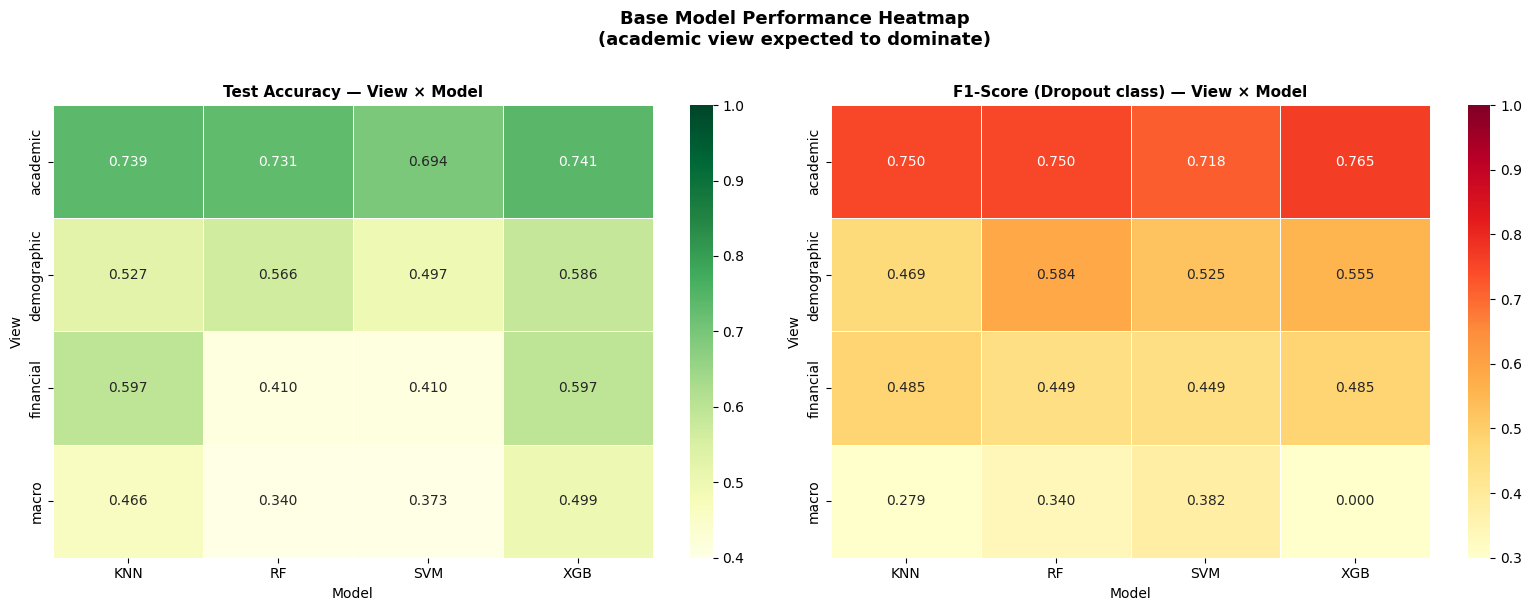

In [14]:
results_df = pd.DataFrame(base_results)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Accuracy heatmap (view × model)
pivot_acc = results_df.pivot(index='View', columns='Model', values='Accuracy')
sns.heatmap(pivot_acc, ax=axes[0], annot=True, fmt='.3f', cmap='YlGn',
            linewidths=0.5, vmin=0.4, vmax=1.0)
axes[0].set_title('Test Accuracy — View × Model', fontsize=11, fontweight='bold')

# F1 Dropout heatmap (view × model)
pivot_f1d = results_df.pivot(index='View', columns='Model', values='F1_dropout')
sns.heatmap(pivot_f1d, ax=axes[1], annot=True, fmt='.3f', cmap='YlOrRd',
            linewidths=0.5, vmin=0.3, vmax=1.0)
axes[1].set_title('F1-Score (Dropout class) — View × Model', fontsize=11, fontweight='bold')

plt.suptitle('Base Model Performance Heatmap\n(academic view expected to dominate)',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

---
## 9. OOF Score Comparison — All Views & Models

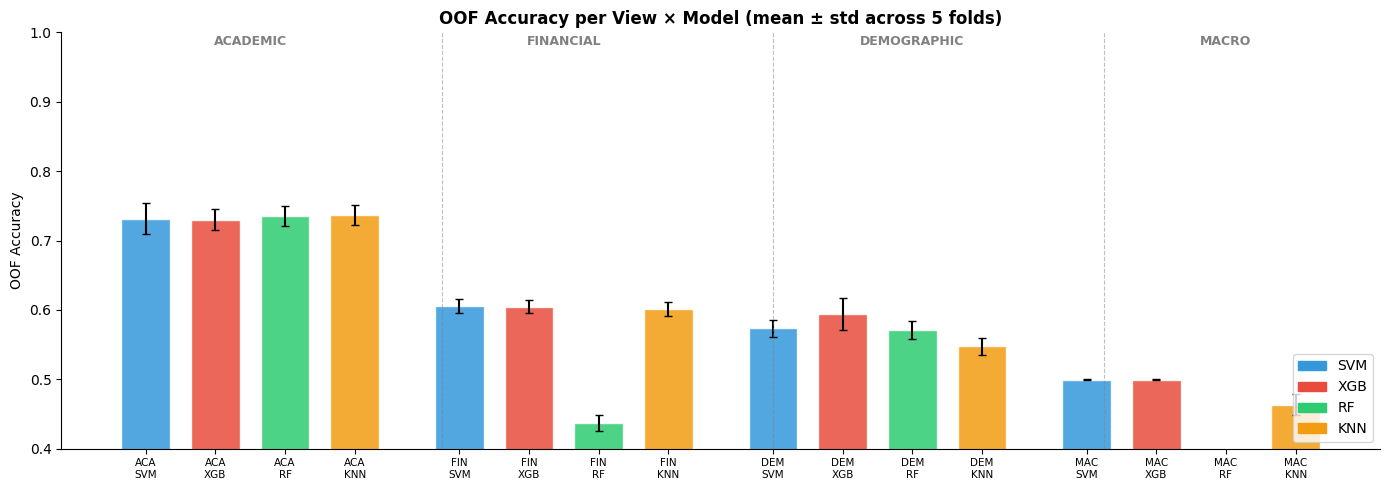

In [15]:
fig, ax = plt.subplots(figsize=(14, 5))

x_positions = []
x_labels    = []
x_pos = 0

colors_model = {'SVM': '#3498db', 'XGB': '#e74c3c', 'RF': '#2ecc71', 'KNN': '#f39c12'}

for view_name in view_order:
    for model_name in ['SVM', 'XGB', 'RF', 'KNN']:
        fold_accs = all_oof_scores[view_name][model_name]
        mean_acc  = np.mean(fold_accs)
        std_acc   = np.std(fold_accs)
        ax.bar(x_pos, mean_acc, color=colors_model[model_name], alpha=0.85,
               width=0.7, edgecolor='white')
        ax.errorbar(x_pos, mean_acc, yerr=std_acc, fmt='none',
                    color='black', capsize=3, linewidth=1.5)
        x_positions.append(x_pos)
        x_labels.append(f"{view_name[:3].upper()}\n{model_name}")
        x_pos += 1
    x_pos += 0.5   # gap between views

ax.set_xticks(x_positions)
ax.set_xticklabels(x_labels, fontsize=7.5)
ax.set_ylabel('OOF Accuracy')
ax.set_title('OOF Accuracy per View × Model (mean ± std across 5 folds)',
             fontsize=12, fontweight='bold')
ax.set_ylim(0.4, 1.0)
ax.spines[['top', 'right']].set_visible(False)

from matplotlib.patches import Patch
legend_elements = [Patch(color=c, label=m) for m, c in colors_model.items()]
ax.legend(handles=legend_elements, loc='lower right')

# Add vertical lines between views
for xv in [4.25, 9.0, 13.75]:
    ax.axvline(xv, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)

# View labels
for xv, vn in zip([1.5, 6.0, 11.0, 15.5], view_order):
    ax.text(xv, 0.97, vn.upper(), ha='center', fontsize=9, fontweight='bold',
            color='gray', transform=ax.get_xaxis_transform())

plt.tight_layout()
plt.show()

---
## 10. Save Models & Results for SHAP/LIME Notebook

In [16]:
modeling_bundle = {
    # Level-0 trained models
    'all_models'       : all_models,          # {view: {model_name: fitted_model}}
    # Meta-features
    'meta_train'       : meta_train,           # (n_train, 48)
    'meta_test'        : meta_test,            # (n_test, 48)
    'meta_columns'     : meta_columns,         # column names
    # Meta-learner
    'meta_learner'     : meta_learner,
    # Bootstrap results
    'prob_mean'        : prob_mean,
    'prob_std'         : prob_std,
    'prob_ci_lo'       : prob_ci_lo,
    'prob_ci_hi'       : prob_ci_hi,
    'y_pred_boot'      : y_pred_boot,
    # Triage
    'tiers'            : tiers,
    # Metadata
    'class_names'      : class_names,
    'view_order'       : view_order,
    'model_names'      : model_names,
    # OOF probs & scores
    'all_oof_probs'    : all_oof_probs,
    'all_test_probs'   : all_test_probs,
    'all_oof_scores'   : all_oof_scores,
}

with open('../data/modeling_bundle.pkl', 'wb') as f:
    pickle.dump(modeling_bundle, f)

print("Saved: ../data/modeling_bundle.pkl")
print(f"\nFinal Results Summary:")
print(f"  Accuracy (bootstrap) : {accuracy_score(y_test, y_pred_boot):.4f}")
print(f"  F1 macro             : {f1_score(y_test, y_pred_boot, average='macro'):.4f}")
print(f"  F1 Dropout class     : {f1_score(y_test, y_pred_boot, average=None, labels=[2])[0]:.4f}")
try:
    print(f"  ROC AUC (OvR)        : {roc_auc_score(y_test, prob_mean, multi_class='ovr', average='macro'):.4f}")
except:
    pass
print(f"\nNext step → 04_shap_lime.ipynb")

Saved: ../data/modeling_bundle.pkl

Final Results Summary:
  Accuracy (bootstrap) : 0.7401
  F1 macro             : 0.7099
  F1 Dropout class     : 0.7833
  ROC AUC (OvR)        : 0.8862

Next step → 04_shap_lime.ipynb


---
## Summary

```
MULTI-VIEW STACKING ENSEMBLE — PIPELINE COMPLETE
══════════════════════════════════════════════════════════════════

Level-0 Base Models (4 per view, 4 views = 16 models total):
  SVM   → kernel=rbf, probability=True, class_weight=balanced
  XGB   → 200 trees, max_depth=5, mlogloss eval
  RF    → 200 trees, max_depth=10, class_weight=balanced
  KNN   → k=15, distance-weighted

OOF Training:
  5-fold StratifiedKFold → no leakage from train to meta-learner
  Meta-features: 4 views × 4 models × 3 classes = 48 features

Meta-Learner:
  Bayesian Logistic Regression (L2 regularized, C=0.5)
  Uncertainty via Bootstrap (n=200 iterations)
  → 3 confidence tiers: High / Medium / Low (needs review)

Next → 04_shap_lime.ipynb
  SHAP Level 1: feature importance di best base model per view
  SHAP Level 2: meta-feature (which view/model) contribution
  LIME         : per-student local explanation
══════════════════════════════════════════════════════════════════
```